# Analasys of the outcome of the acceleration model
In this notebook we perform the analysis for the outcome of the acceleration model. This includes the creation of ratemaps, spacial autocorellograms, different metrics etc.

## Importing

In [1]:
import numpy as np
import scipy 
import scores
import pickle
from scipy import ndimage

from functools import reduce
from polygon import get_polygon
import scores

from scipy.ndimage import maximum_filter
from tqdm import tqdm

import os

import warnings
warnings.filterwarnings('ignore')

# viz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

## Defining data path, variables and loading data

In [2]:
""" 

    where am i?

"""
#0 = full and 1 = max
full_or_max = 1
type_options =  ['clean', 'softmax', 'softmax_01', 'softmax_02', 'softmax_03', 'softmax_04', 'softmax_05']

options_90 = [[0.45 ,0.44 ,0.46 ,0.45 ,0.42 ,0.44 ,0.45], [0.89 ,0.88 ,0.9 ,0.9 ,0.86 ,0.89 ,0.89 ]]

options_60 = [[0.21, 0.21, 0.21, 0.22, 0.21, 0.22, 0.22], [0.53, 0.54, 0.53, 0.56, 0.54, 0.55, 0.53]]

type_index = 4

#Defining the final variables
train_type = type_options[type_index]

value_90 = options_90[full_or_max][type_index]
value_60 = options_60[full_or_max][type_index]

PATH = os.getcwd()
data_path = PATH.replace( '01_square', '' ) + '/data/01_square_1000000_4_84_512/' + train_type + '/'

print( f'PATH: { PATH }' )
print( f'data_path: { data_path }' )

PATH: /home/rannarz/thesis_round2/post_training
data_path: /home/rannarz/thesis_round2/post_training/data/01_square_1000000_4_84_512/softmax_03/


In [3]:
""" 

    load raw data

"""

res = np.load( data_path + 'raw/res_999.npy', allow_pickle=True, encoding='latin1' )
res = dict( res.item() )

scores_btln = np.load( data_path + 'raw/scores_999.npy', allow_pickle=True, encoding='latin1' )
scores_btln = dict( scores_btln.item() )

print( f'res: { res.keys() }' )
print( f'scores: { scores_btln.keys() }' )

res: dict_keys(['lstm', 'bottleneck', 'pos_xy'])
scores: dict_keys(['btln_60_separation', 'lstm_90', 'btln_60', 'btln_90_separation', 'btln_90', 'lstm_60'])


## Creating the ratemaps for each hidden unit

In [4]:
"""  

    build ratemap

"""

save = True

polygon_ = get_polygon( 'square', 2.2**2, factor=1 )

res_pos = res['pos_xy']
res_btln = res['bottleneck']

print('')
print( f'sample_res_pos: { res_pos.shape }' )
print( f'sample_res_btln: { res_btln.shape }' )
print( f'Number of units in the hidden layer: {res_btln.shape[2]}')
print('')

starts = [0.2] * 10
ends = np.linspace(0.4, 1.0, num=10)
masks_parameters = zip(starts, ends.tolist())

# coord range
min_x, min_y, max_x, max_y = polygon_.bounds
coord_range = ( (min_x, max_x), (min_y, max_y) )

res_ = 55
latest_epoch_scorer = scores.GridScorer( res_, coord_range, masks_parameters )

# concatenate trajectories
xy = res_pos.reshape(-1, res_pos.shape[-1])
act = res_btln.reshape(-1, res_btln.shape[-1])
n_units = act.shape[1]

# get ratemap for each unit
ratemap = np.array([ latest_epoch_scorer.calculate_ratemap(xy[:, 0], xy[:, 1], act[:, i]) for i in tqdm(range(n_units)) ])

if save:
    np.save( data_path + 'grid_scores/ratemap.npy', ratemap )
    print( 'saved' )


sample_res_pos: (4000, 100, 2)
sample_res_btln: (4000, 100, 512)
Number of units in the hidden layer: 512



100%|█████████████████████████████████████████████████████████████| 512/512 [00:08<00:00, 62.48it/s]

saved


# Creating the spatial autocorellograms

---------- computing sac maximum mask ----------


100%|█████████████████████████████████████████████████████████████| 512/512 [02:29<00:00,  3.42it/s]


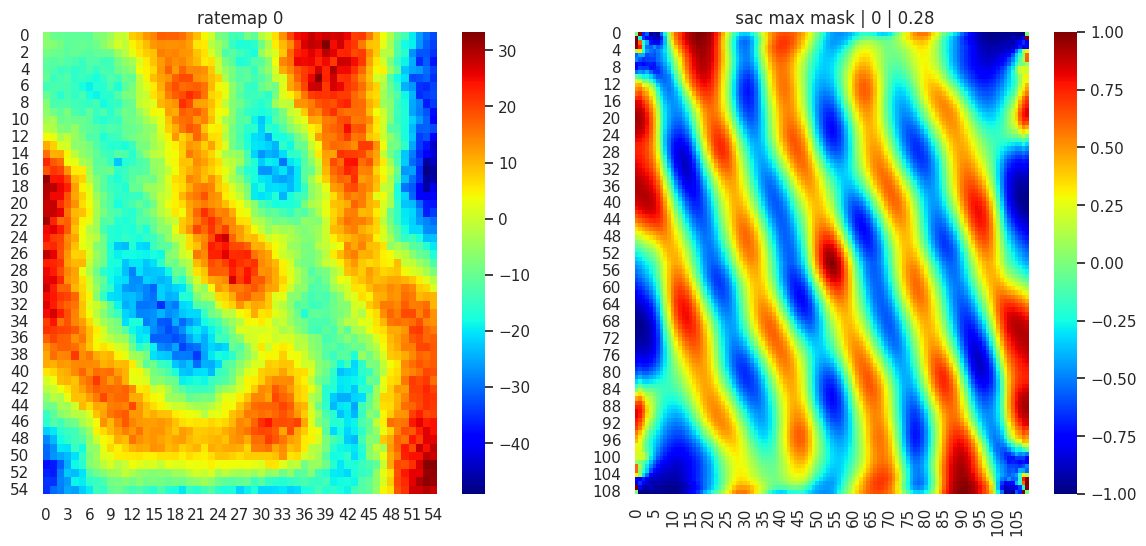

In [5]:
""" 

    grid scores dataset

"""

save = True

polygon_ = get_polygon( 'square', 2.2**2, factor=1 )

res_ = 55

# coord range
min_x, min_y, max_x, max_y = polygon_.bounds
coord_range = ( (min_x, max_x), (min_y, max_y) )

s = ratemap

#sample_idx = np.random.randint( 0, len(s) )
sample_idx = 0

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap( s[ sample_idx ], ax=ax[0], cmap='jet' )
ax[0].set_title( f'ratemap { sample_idx }' )

# only max mask
print( '---------- computing sac maximum mask ----------' )

starts = [0.2] * 10
ends = np.linspace(0.4, 1.0, num=10)
masks_parameters = zip(starts, ends.tolist())

latest_epoch_scorer = scores.GridScorer( res_, coord_range, masks_parameters )

score_60, score_90, max_60_mask, max_90_mask, sac = zip( * [ latest_epoch_scorer.get_scores(rate_map) for rate_map in tqdm(s) ] )

if save:

    np.save( data_path + 'grid_scores/sac/max/' + 'score_60.npy', score_60 )
    np.save( data_path + 'grid_scores/sac/max/' + 'score_90.npy', score_90 )
    np.save( data_path + 'grid_scores/sac/max/' + 'max_60_mask.npy', max_60_mask )
    np.save( data_path + 'grid_scores/sac/max/' + 'max_90_mask.npy', max_90_mask )
    np.save( data_path + 'grid_scores/sac/max/' + 'sac.npy', sac )

sns.heatmap( sac[ sample_idx ], ax=ax[1], cmap='jet' )
ax[1].set_title( f' sac max mask | { sample_idx } | { round(score_60[ sample_idx ], 2) }' )

plt.show()

# Calculating the grid spacing

## Peak filtering

In [6]:
""" 

    peak filtering

"""

def peak_filter( sac, res_, hc_centre=True, footprint=( 5, 5 ) ):

    if hc_centre:

        centre = sac.shape[0] // 2
        global_max_pos = ( centre, centre )
        #print( f'global_max_pos: { global_max_pos }' )

    else:

        global_max_pos = np.unravel_index( np.argmax( sac ), sac.shape )

    local_max_pos = maximum_filter( sac, footprint=np.ones( footprint ), mode='wrap' )

    dists = []
    lm_pos = []
    for pos in np.argwhere( local_max_pos == sac ):

        dist = np.linalg.norm( np.array( global_max_pos ) - np.array( pos ) )

        if dist <= res_:

            dists.append( dist )
            lm_pos.append( pos )

    lm_pos = np.array( lm_pos )

    #dists = [ np.linalg.norm( np.array( global_max_pos ) - np.array( pos ) ) for pos in np.argwhere( local_max_pos == sac ) ]

    #local_max_pos = np.argwhere( local_max_pos == sac )

    return global_max_pos, lm_pos, dists

# get distances
save = True

res_ = 55

global_mat = []
local_mat = []
dists_mat = []

for corr in tqdm( sac ):

    global_max_pos, local_max_pos, dists = peak_filter( corr, res_ )

    global_mat.append( global_max_pos )
    local_mat.append( local_max_pos )
    dists_mat.append( dists )

median_mat = [ np.sort(np.array( x )) for x in dists_mat ]
median_mat = [ x[ np.nonzero(x)[0] ][:6] for x in median_mat ]
median_mat = [ np.median( x ) if len(x) > 0 else np.nan for x in median_mat ]
#median_mat = [ np.median( x[ np.nonzero(x)[0] ][:6] ) for x in median_mat ]

if save:

    with open( data_path + 'grid_scores/sac/max/global_mat_014.pkl', 'wb' ) as f:
        pickle.dump( global_mat, f )

    with open( data_path + 'grid_scores/sac/max/local_mat_014.pkl', 'wb' ) as f:
        pickle.dump( local_mat, f )

    with open( data_path + 'grid_scores/sac/max/dists_mat_014.pkl', 'wb' ) as f:
        pickle.dump( dists_mat, f )

    with open( data_path + 'grid_scores/sac/max/median_mat_014.pkl', 'wb' ) as f:
        pickle.dump( median_mat, f )

100%|███████████████████████████████████████████████████████████| 512/512 [00:00<00:00, 2459.94it/s]


# Calculating the border scores
In this section we are going to calculate the border scores and showing some examples.

In [7]:
""" 

    border score

"""

def border_score( ratemap, res, width ):

    pix_area = ((100**2)*(width**2))/(res**2) # ??

    rm_th = ratemap > np.nanmax( ratemap * 0.1 )
    rm_comps, ncomps = ndimage.measurements.label( rm_th )

    # keep fields with area > 200 cm^2
    masks = []
    nfields = 0
    for i in range(1, ncomps+1):

        mask = ( rm_comps == i ).reshape( res, res )

        if mask.sum()*pix_area > 200:
            
            masks.append( mask )
            nfields += 1

    field_mean = [ m.mean() for m in masks ]

    # ---------------

    rm_ub_th = ratemap > np.nanmax( ratemap * 0.5 )
    rm_ub_comps, ncomps_ub = ndimage.measurements.label( rm_ub_th )

    masks_ub = []
    nfields_ub = 0
    for i in range(1, ncomps_ub+1):

        mask = ( rm_ub_comps == i ).reshape( res, res )

        if mask.sum()*pix_area > 20:
            
            masks_ub.append( mask )
            nfields_ub += 1

    # ---------------

    # get max coverage
    cm_max = 0
    for mask in masks:

        mask = masks[0]
        n_cov = mask[0].mean()
        s_cov = mask[-1].mean()
        e_cov = mask[:,0].mean()
        w_cov = mask[:,-1].mean()
        cm = np.max([n_cov,s_cov,e_cov,w_cov])

        if cm>cm_max:
            cm_max = cm

    # distance to nearest wall
    x,y = np.mgrid[:res,:res] + 1
    x = x.ravel()
    y = y.ravel()
    xmin = np.min(np.vstack([x,res+1-x]),0)
    ymin = np.min(np.vstack([y,res+1-y]),0)
    dweight = np.min(np.vstack([xmin,ymin]),0).reshape(res,res)
    dweight = dweight*width/res

    # mean firing distances
    dms = []
    for mask in masks:
        field = ratemap[mask]
        field /= field.sum()   # normalize
        dm = (field*dweight[mask]).sum()
        dms.append(dm)
    dm = np.nanmean(dms) / (width/2)
    border_score = (cm_max-dm)/(cm_max+dm)

    return border_score, cm_max, dm, field_mean, len( masks_ub )

polygon_ = get_polygon( 'square', area=2.20**2, factor=1 )

# coord range
min_x, min_y, max_x, max_y = polygon_.bounds
coord_range = ( (min_x, max_x), (min_y, max_y) )

width = max_x - min_x

res = 55

border_scores_mat = []
cms_mat = []
dms_mat = []
fields_mean_mat = []
fields_count_mat = []

for i in tqdm( range( ratemap.shape[0] ) ):

    ratemap_l = ratemap[i]
    bscore, cm_max, dm, field_mean, field_count = border_score( ratemap_l, res, width )

    border_scores_mat.append( bscore )
    cms_mat.append( cm_max )
    dms_mat.append( dm )
    fields_mean_mat.append( field_mean )
    fields_count_mat.append( field_count )

border_scores_mat = np.array( border_scores_mat )
cms_mat = np.array( cms_mat )
dms_mat = np.array( dms_mat )
fields_count_mat = np.array( fields_count_mat )

print('')
print( f'border_scores_mat: { border_scores_mat.shape }' )
print( f'border score nan: { np.isnan(border_scores_mat).sum() }' )
print( f'cms_mat: { cms_mat.shape }' )
print( f'dms_mat: { dms_mat.shape }' )
print( f'fields_mean_mat: { len(fields_mean_mat) }' )
print( f'fields_count_mat: { fields_count_mat.shape }' )
print('')

save = True

if save:

    #np.save( data_path + 'grid_scores/sac/max/border.npy', sac_max_border_mat )
    np.save( data_path + 'grid_scores/border_014.npy', border_scores_mat )
    
    with open( data_path + 'grid_scores/fields_mean_014.pkl', 'wb' ) as f:
        pickle.dump( fields_mean_mat, f )

    np.save( data_path + 'grid_scores/fields_count_014.npy', fields_count_mat )

100%|███████████████████████████████████████████████████████████| 512/512 [00:00<00:00, 1416.67it/s]


border_scores_mat: (512,)
border score nan: 0
cms_mat: (512,)
dms_mat: (512,)
fields_mean_mat: 512
fields_count_mat: (512,)



# Performing filtering
In this section we filter out all of the grid cells, plot the remaining units and display some simple analysis.

## Loading the data

In [8]:
"""  

    load data

"""

ratemap_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/' ) if 'ratemap' in x and not 'random' in x ])
ratemap_mat = [ np.load( data_path + 'grid_scores/' + x ) for x in ratemap_mat ]

border_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/' ) if 'border' in x ])
border_mat = [ np.load( data_path + 'grid_scores/' + x ) for x in border_mat ]

fields_max_mat_aux = sorted([ x for x in os.listdir( data_path + 'grid_scores/' ) if 'fields_mean' in x ])
fields_max_mat = []

for mat in fields_max_mat_aux:
    aux = []
    with open( data_path + 'grid_scores/' + mat, 'rb' ) as f:
        for l in pickle.load( f ):
            aux.append( np.max(l) )

    fields_max_mat.append( aux )

fields_count_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/' ) if 'fields_count' in x ])
fields_count_mat = [ np.load( data_path + 'grid_scores/' + x ) for x in fields_count_mat ]

sac_max_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/sac/max/' ) if 'sac' in x ])
sac_max_mat = [ np.load( data_path + 'grid_scores/sac/max/' + x ) for x in sac_max_mat ]

sac_max_score_60_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/sac/max/' ) if 'score_60' in x ])
sac_max_score_60_mat = [ np.load( data_path + 'grid_scores/sac/max/' + x ) for x in sac_max_score_60_mat ]

sac_max_score_90_mat = sorted([ x for x in os.listdir( data_path + 'grid_scores/sac/max/' ) if 'score_90' in x ])
sac_max_score_90_mat = [ np.load( data_path + 'grid_scores/sac/max/' + x ) for x in sac_max_score_90_mat ]

sac_max_median_mat_aux = sorted([ x for x in os.listdir( data_path + 'grid_scores/sac/max/' ) if 'median' in x ])
sac_max_median_mat = []

for mat in sac_max_median_mat_aux:
    with open( data_path + 'grid_scores/sac/max/' + mat, 'rb' ) as f:
        sac_max_median_mat.append( pickle.load( f ) )

print('')
print( f'ratemap_mat: { len(ratemap_mat) }' )
print( f'sac_max_mat: { len(sac_max_mat) }' )
print( f'sac_max_border_mat: { len(border_mat) }' )
print( f'fields_mean_mat: { len(fields_max_mat) }' )
print( f'fields_count_mat: { len(fields_count_mat) }' )
print( f'sac_max_score_60_mat: { len(sac_max_score_60_mat) }' )
print( f'sac_max_score_90_mat: { len(sac_max_score_90_mat) }' )
print( f'sac_max_median_mat: { len(sac_max_median_mat) }' )
print('')


ratemap_mat: 1
sac_max_mat: 1
sac_max_border_mat: 1
fields_mean_mat: 1
fields_count_mat: 1
sac_max_score_60_mat: 1
sac_max_score_90_mat: 1
sac_max_median_mat: 1



### Displaying the distribution of different computations

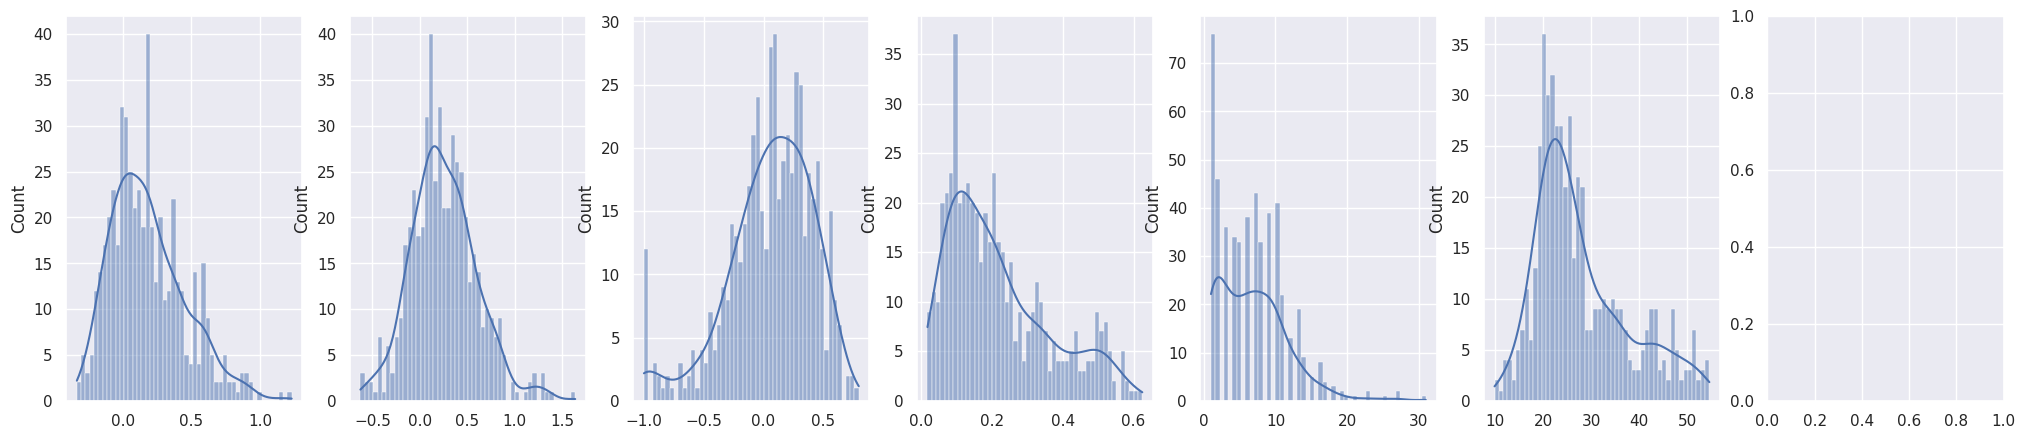

In [9]:
""" 

    viz rates/distances

"""

fig, axs = plt.subplots( 1, 7, figsize=( 25, 5 ) )

sns.histplot( sac_max_score_60_mat, ax=axs[0], bins=50, kde=True, legend=False )

sns.histplot( sac_max_score_90_mat, ax=axs[1], bins=50, kde=True, legend=False )

sns.histplot( border_mat, ax=axs[2], bins=50, kde=True, legend=False )

sns.histplot( fields_max_mat, ax=axs[3], bins=50, kde=True, legend=False )

sns.histplot( fields_count_mat, ax=axs[4], bins=50, kde=True, legend=False )

sns.histplot( sac_max_median_mat, ax=axs[5], bins=50, kde=True, legend=False )

#sns.histplot( peak_count_mat, ax=axs[6], bins=50, kde=True, legend=False )

plt.show()

## Filtering out the units that have grid score over the baseline

In [10]:
"""  

    filtering

"""

sac_max_score_90_th = ( -np.inf, value_90 ) 

sac_max_score_60_th = ( value_60, np.inf )

sac_max_median_th = ( -np.inf, np.inf )

border_th = ( -np.inf, 0.5 )

field_th = ( -np.inf, 0.2 )

count_th = ( 2, 100 )

# filter

sac_max_score_90_filt_idx = []
for mat in sac_max_score_90_mat:
    sac_max_score_90_filt_idx.append(np.where( ( mat > sac_max_score_90_th[0] ) & ( mat < sac_max_score_90_th[1] ) )[0])

sac_max_score_60_filt_idx = []
for mat in sac_max_score_60_mat:
    sac_max_score_60_filt_idx.append(np.where( ( mat > sac_max_score_60_th[0] ) & ( mat < sac_max_score_60_th[1] ) )[0])

sac_max_median_filt_idx = []
for mat in sac_max_median_mat:
    sac_max_median_filt_idx.append(np.where( ( np.array(mat).flatten() > sac_max_median_th[0] ) & ( np.array(mat).flatten() < sac_max_median_th[1] ) )[0])

border_filt_idx = []
for mat in border_mat:
    border_filt_idx.append(np.where( ( mat > border_th[0] ) & ( mat < border_th[1] ) )[0])

fields_filt_idx = []
for mat in fields_max_mat:
    fields_filt_idx.append(np.where( ( np.array(mat) > field_th[0] ) & ( np.array(mat) < field_th[1] ) )[0])

fields_count_filt_idx = []
for mat in fields_count_mat:
    fields_count_filt_idx.append(np.where( ( mat > count_th[0] ) & ( mat < count_th[1] ) )[0])

sac_max_filter_idx = []
for idx in range( len( sac_max_score_90_filt_idx ) ):
    sac_max_filter_idx.append( reduce( np.intersect1d, ( sac_max_score_90_filt_idx[idx], sac_max_score_60_filt_idx[idx], sac_max_median_filt_idx[idx], border_filt_idx[idx], fields_filt_idx[idx], fields_count_filt_idx[idx]) ) )

sac_max_score_90_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    sac_max_score_90_filt.append( sac_max_score_90_mat[idx][ sac_max_filter_idx[idx] ] )

sac_max_score_60_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    sac_max_score_60_filt.append( sac_max_score_60_mat[idx][ sac_max_filter_idx[idx] ] )

sac_max_median_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    sac_max_median_filt.append( np.array(sac_max_median_mat[idx]).flatten()[ sac_max_filter_idx[idx] ] )

border_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    border_filt.append( border_mat[idx][ sac_max_filter_idx[idx] ] )

fields_max_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    fields_max_filt.append( np.array(fields_max_mat[idx])[ sac_max_filter_idx[idx] ] )

fields_count_filt = []
for idx in range( len( sac_max_filter_idx ) ):
    fields_count_filt.append( fields_count_mat[idx][ sac_max_filter_idx[idx] ] )

print('')
print( f'sac max score 90 filt: { len(sac_max_score_90_filt) }' )
print( f'sac max score 60 filt: { len(sac_max_score_60_filt) }' )
print( f'sac max median filt: { len(sac_max_median_filt) }' )
print( f'border filt: { len(border_filt) }' )
#print( f'fields max filt: { len(fields_max_filt) }' )
#print( f'fields count filt: { len(fields_count_filt) }' )
print('')


sac max score 90 filt: 1
sac max score 60 filt: 1
sac max median filt: 1
border filt: 1



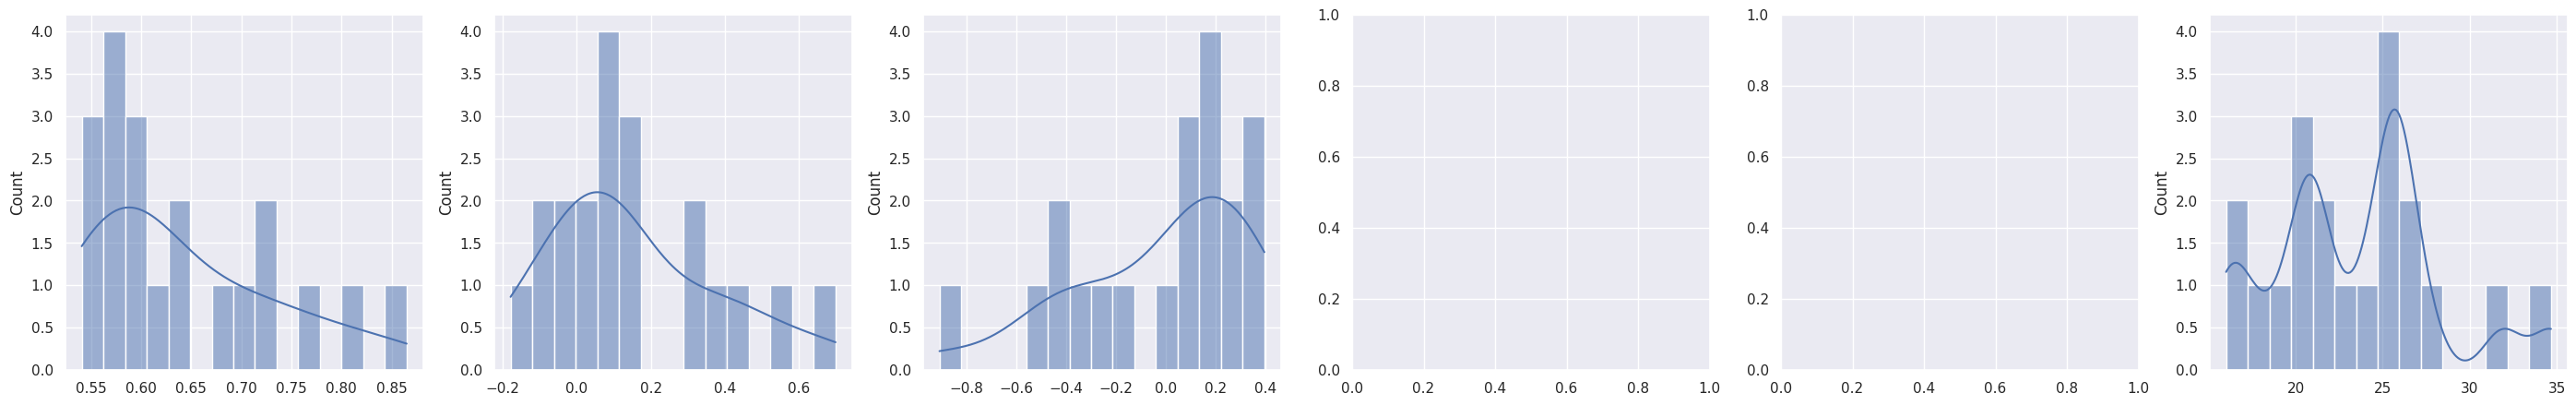

In [11]:
""" 

    viz rates/distances

"""

fig, axs = plt.subplots( 1, 6, figsize=( 35, 5 ) )

sns.histplot( sac_max_score_60_filt, ax=axs[0], bins=15, kde=True, legend=False )

sns.histplot( sac_max_score_90_filt, ax=axs[1], bins=15, kde=True, legend=False )

sns.histplot( border_filt, ax=axs[2], bins=15, kde=True, legend=False )

#sns.histplot( fields_max_filt, ax=axs[3], bins=15, kde=True, legend=False )

#sns.histplot( fields_count_filt, ax=axs[4], bins=15, kde=True, legend=False )

for mat in sac_max_median_filt:
    sns.histplot( mat, ax=axs[5], bins=15, kde=True, legend=False, kde_kws={'bw_adjust': 0.4} )

plt.show()

## Displaying the grid spacing distribution

[ 19  29  50  55  97 123 157 180 205 224 241 293 316 347 423 430 495 502
 505 507]


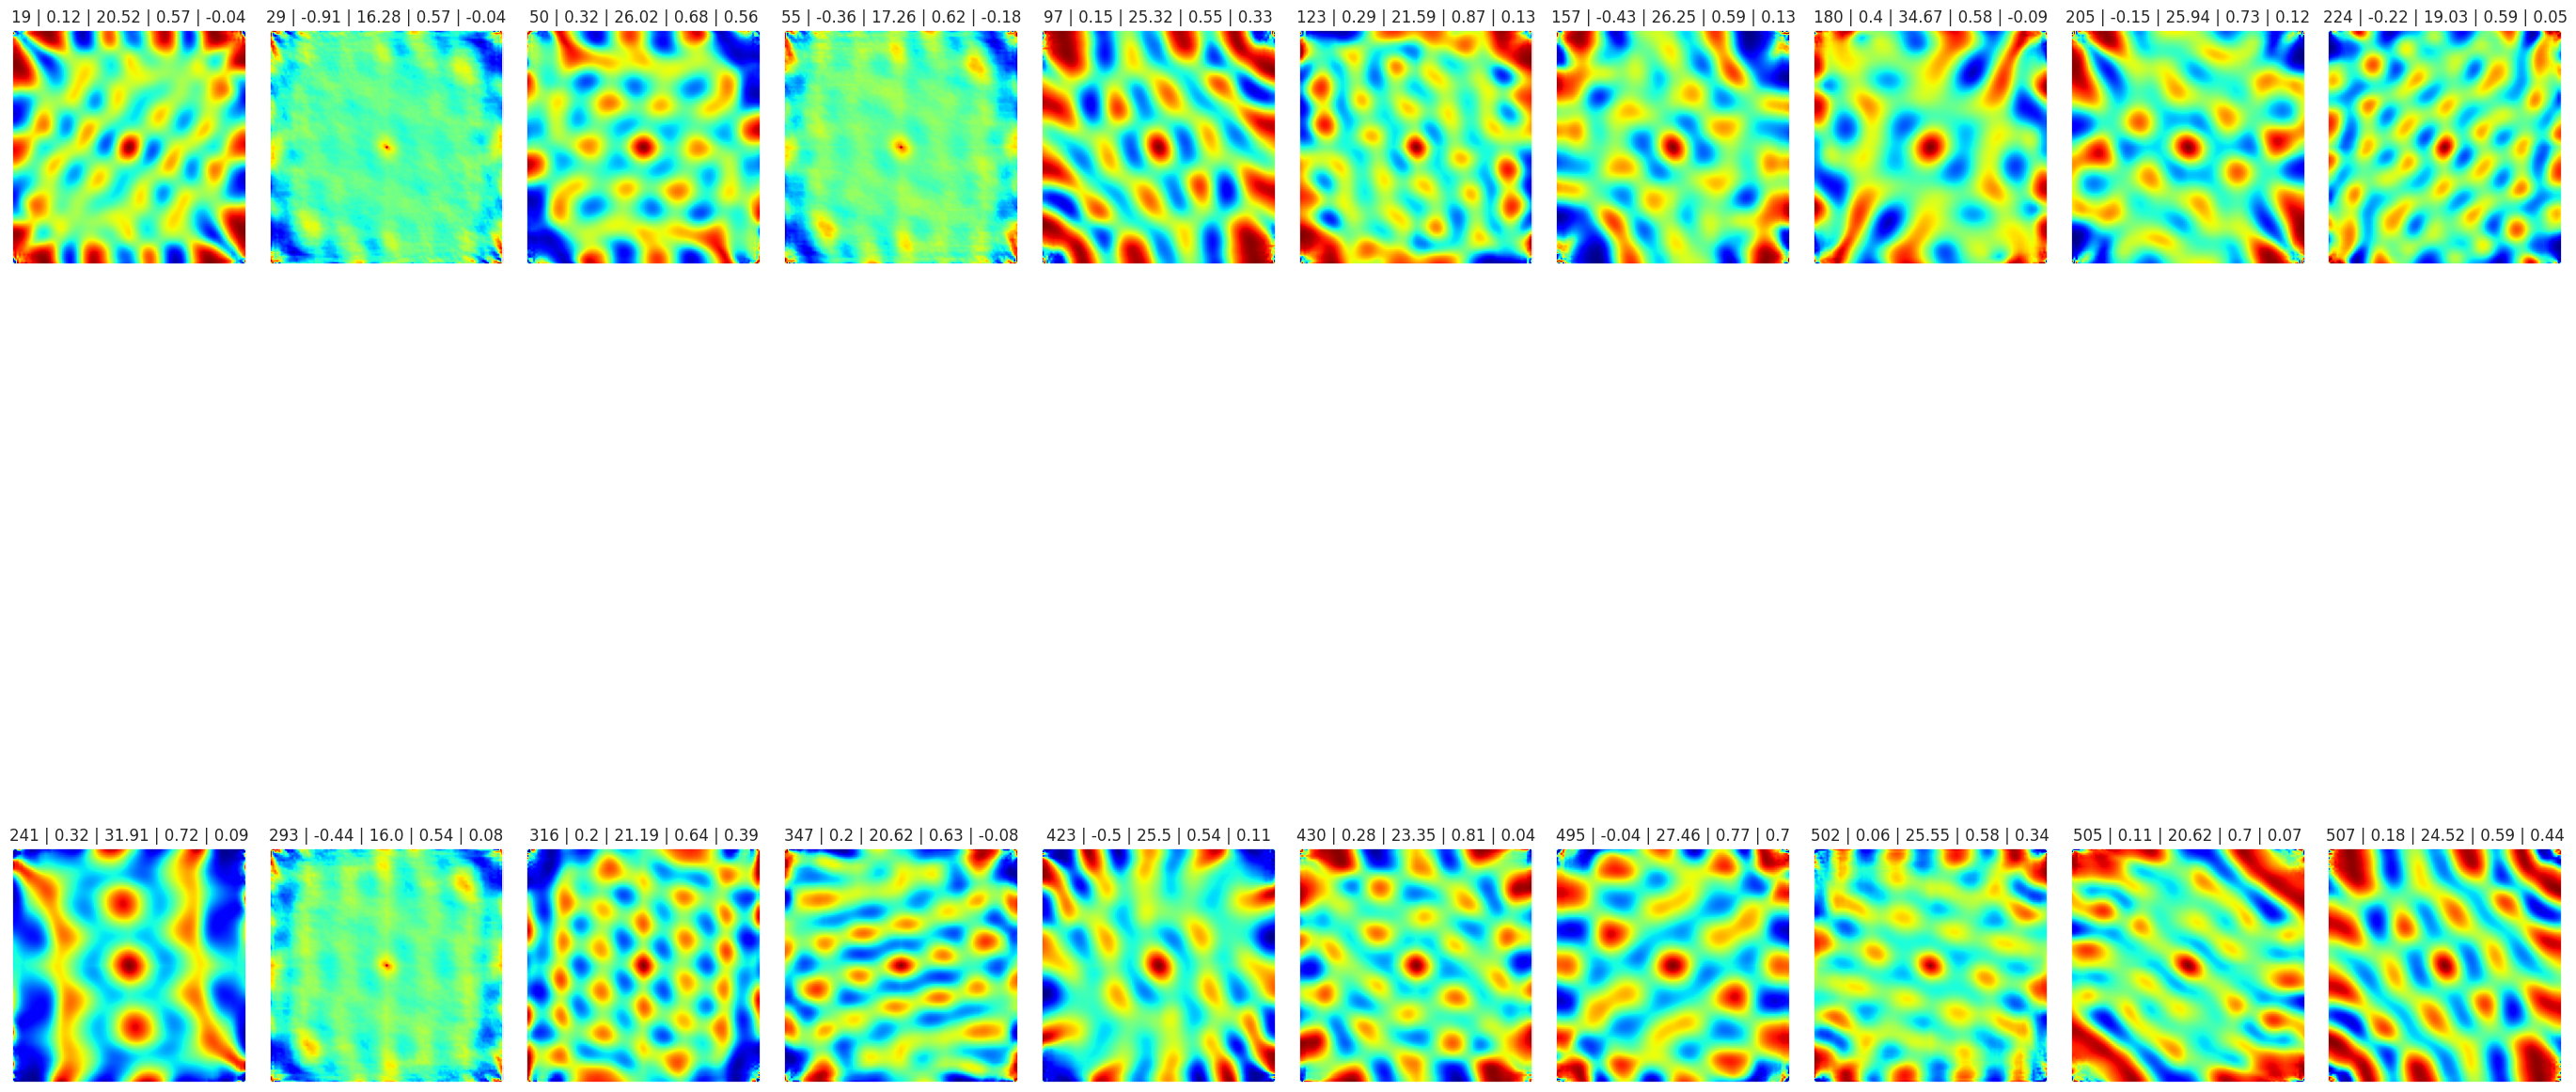

In [12]:
print(sac_max_filter_idx[0])
for i, m in enumerate( sac_max_median_filt ):
    space_sort = sac_max_filter_idx[0] 

    ratemap_sample = ratemap_mat[i][ space_sort ]
    sac_sample = sac_max_mat[i][ space_sort ]

    dim_plot = 10

    fig, axs = plt.subplots( int(np.ceil(space_sort.shape[0] / dim_plot)), dim_plot, figsize=( 35, 20 ) )
    fig.subplots_adjust(wspace=0.1, hspace=0.3)

    n = 0
    for a in range( int(np.ceil(space_sort.shape[0] / dim_plot)) ):
        for b in range( dim_plot ):

            try:

                #axs[a, b].imshow( ratemap_sample[n], cmap='jet', aspect='auto' )
                axs[a, b].imshow( sac_max_mat[i][ space_sort[n] ], cmap='jet' )
                
                axs[a, b].set_xticks([])  # Remove x-axis ticks
                axs[a, b].set_yticks([])  # Remove y-axis ticks

                #axs[a, b].set_title( f'{ space_sort[n] } | { round( border_mat[i][ space_sort[n] ], 2 ) } | { round( sac_max_median_mat[i][ space_sort[n] ], 2 ) } | { round( sac_max_score_60_mat[i][ space_sort[n] ], 2 ) } | { round( sac_max_score_90_mat[i][ space_sort[n] ], 2 ) }' )
                #'{ space_sort[n] } | { round( border_mat[i][ space_sort[n] ], 2 ) } | { round( m[ space_sort[n] ], 2 ) } | { round( sac_max_score_60_mat[ i ][ space_sort[n] ], 2 ) } | { round( sac_max_score_90_mat[ i ][ space_sort[n] ], 2 ) } ' )
                axs[a, b].set_title( f'{ space_sort[n] } | { round( border_mat[i][ space_sort[n] ], 2 ) } | { round( m[ n ], 2 ) } | { round( sac_max_score_60_mat[ i ][ space_sort[n] ], 2 ) } | { round( sac_max_score_90_mat[ i ][ space_sort[n] ], 2 ) }' )
            except:
               axs[a, b].axis('off')

            n += 1

    plt.savefig( f'{ data_path }viz/sac_complete_{ i }.png' )
    plt.show()

## Ploting all of the ratemaps

[ 19  29  50  55  97 123 157 180 205 224 241 293 316 347 423 430 495 502
 505 507]


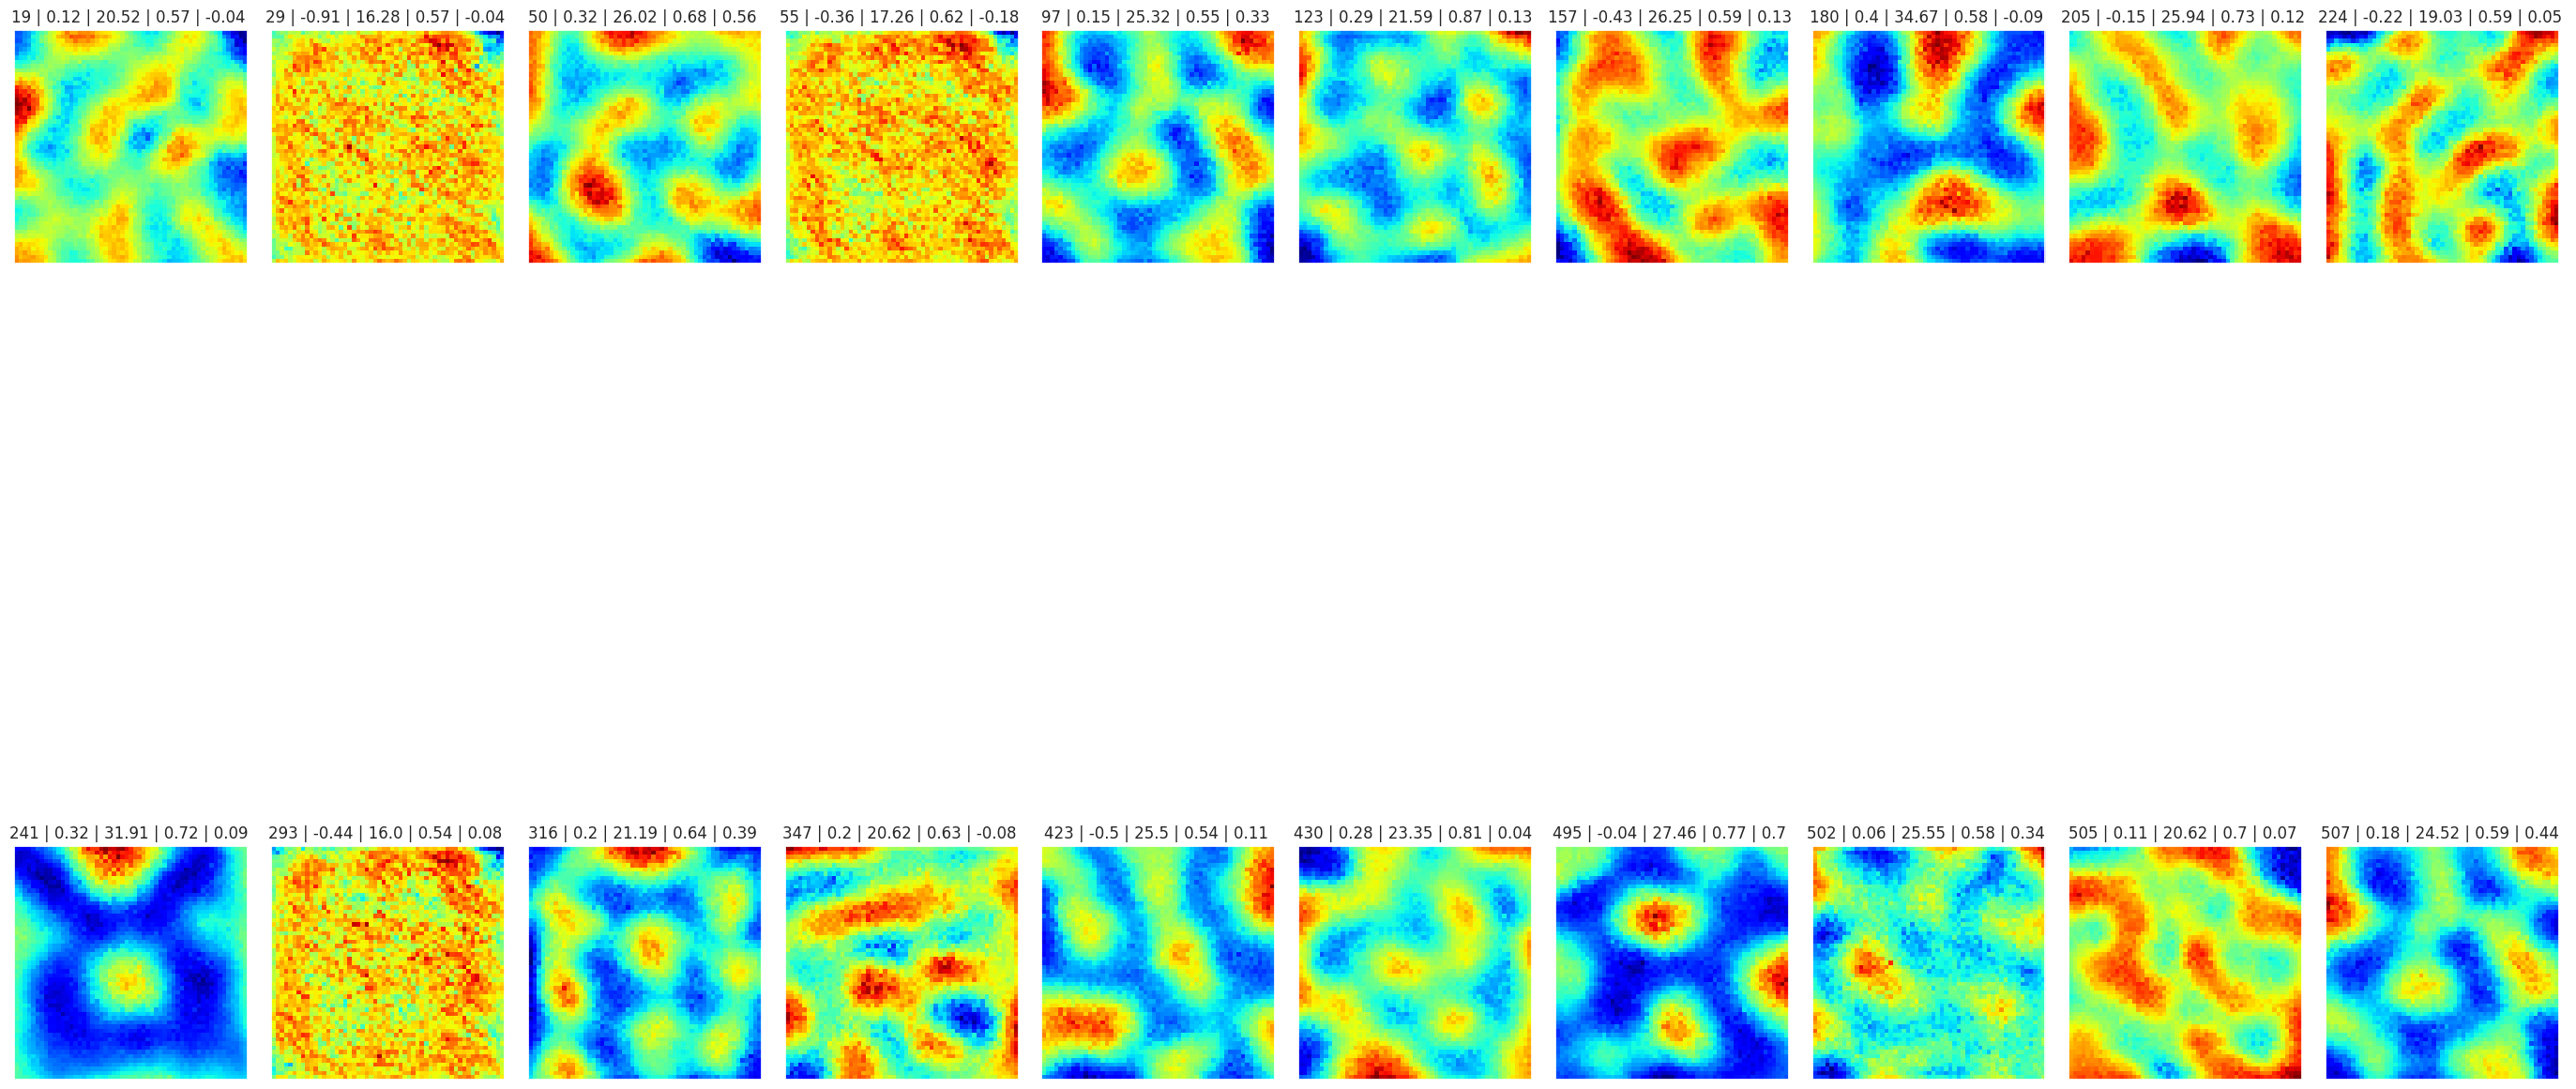

In [13]:
#Plotting all of the ratemaps
for i, m in enumerate( sac_max_median_filt ):

    space_sort_n = sac_max_filter_idx[0] 
    print(space_sort_n)
    ratemap_sample = ratemap_mat[i][ space_sort_n ]
    sac_sample = sac_max_mat[i][ space_sort_n ]

    dim_plot = 10

    fig, axs = plt.subplots( int(np.ceil(space_sort_n.shape[0] / dim_plot)), dim_plot, figsize=( 35, 20 ) )
    fig.subplots_adjust(wspace=0.1, hspace=0.3)

    n = 0
    for a in range( int(np.ceil(space_sort_n.shape[0] / dim_plot)) ):
        for b in range( dim_plot ):

            try:
                axs[a, b].imshow( ratemap[ space_sort_n[n] ], cmap='jet' )
                
                axs[a, b].set_xticks([])  # Remove x-axis ticks
                axs[a, b].set_yticks([])  # Remove y-axis ticks

                axs[a, b].set_title( f'{ space_sort_n[n] } | { round( border_mat[i][ space_sort_n[n] ], 2 ) } | { round( m[ n ], 2 ) } | { round( sac_max_score_60_mat[ i ][ space_sort_n[n] ], 2 ) } | { round( sac_max_score_90_mat[ i ][ space_sort_n[n] ], 2 ) } ' )
            except:
               axs[a, b].axis('off')

            n += 1

    #plt.savefig( f'{ data_path }viz/sac_complete_{ i }.png' )
    plt.show()

### Removing noisy units manually

[ 19  50  97 123 157 180 205 224 241 316 347 423 430 495 502 505 507]


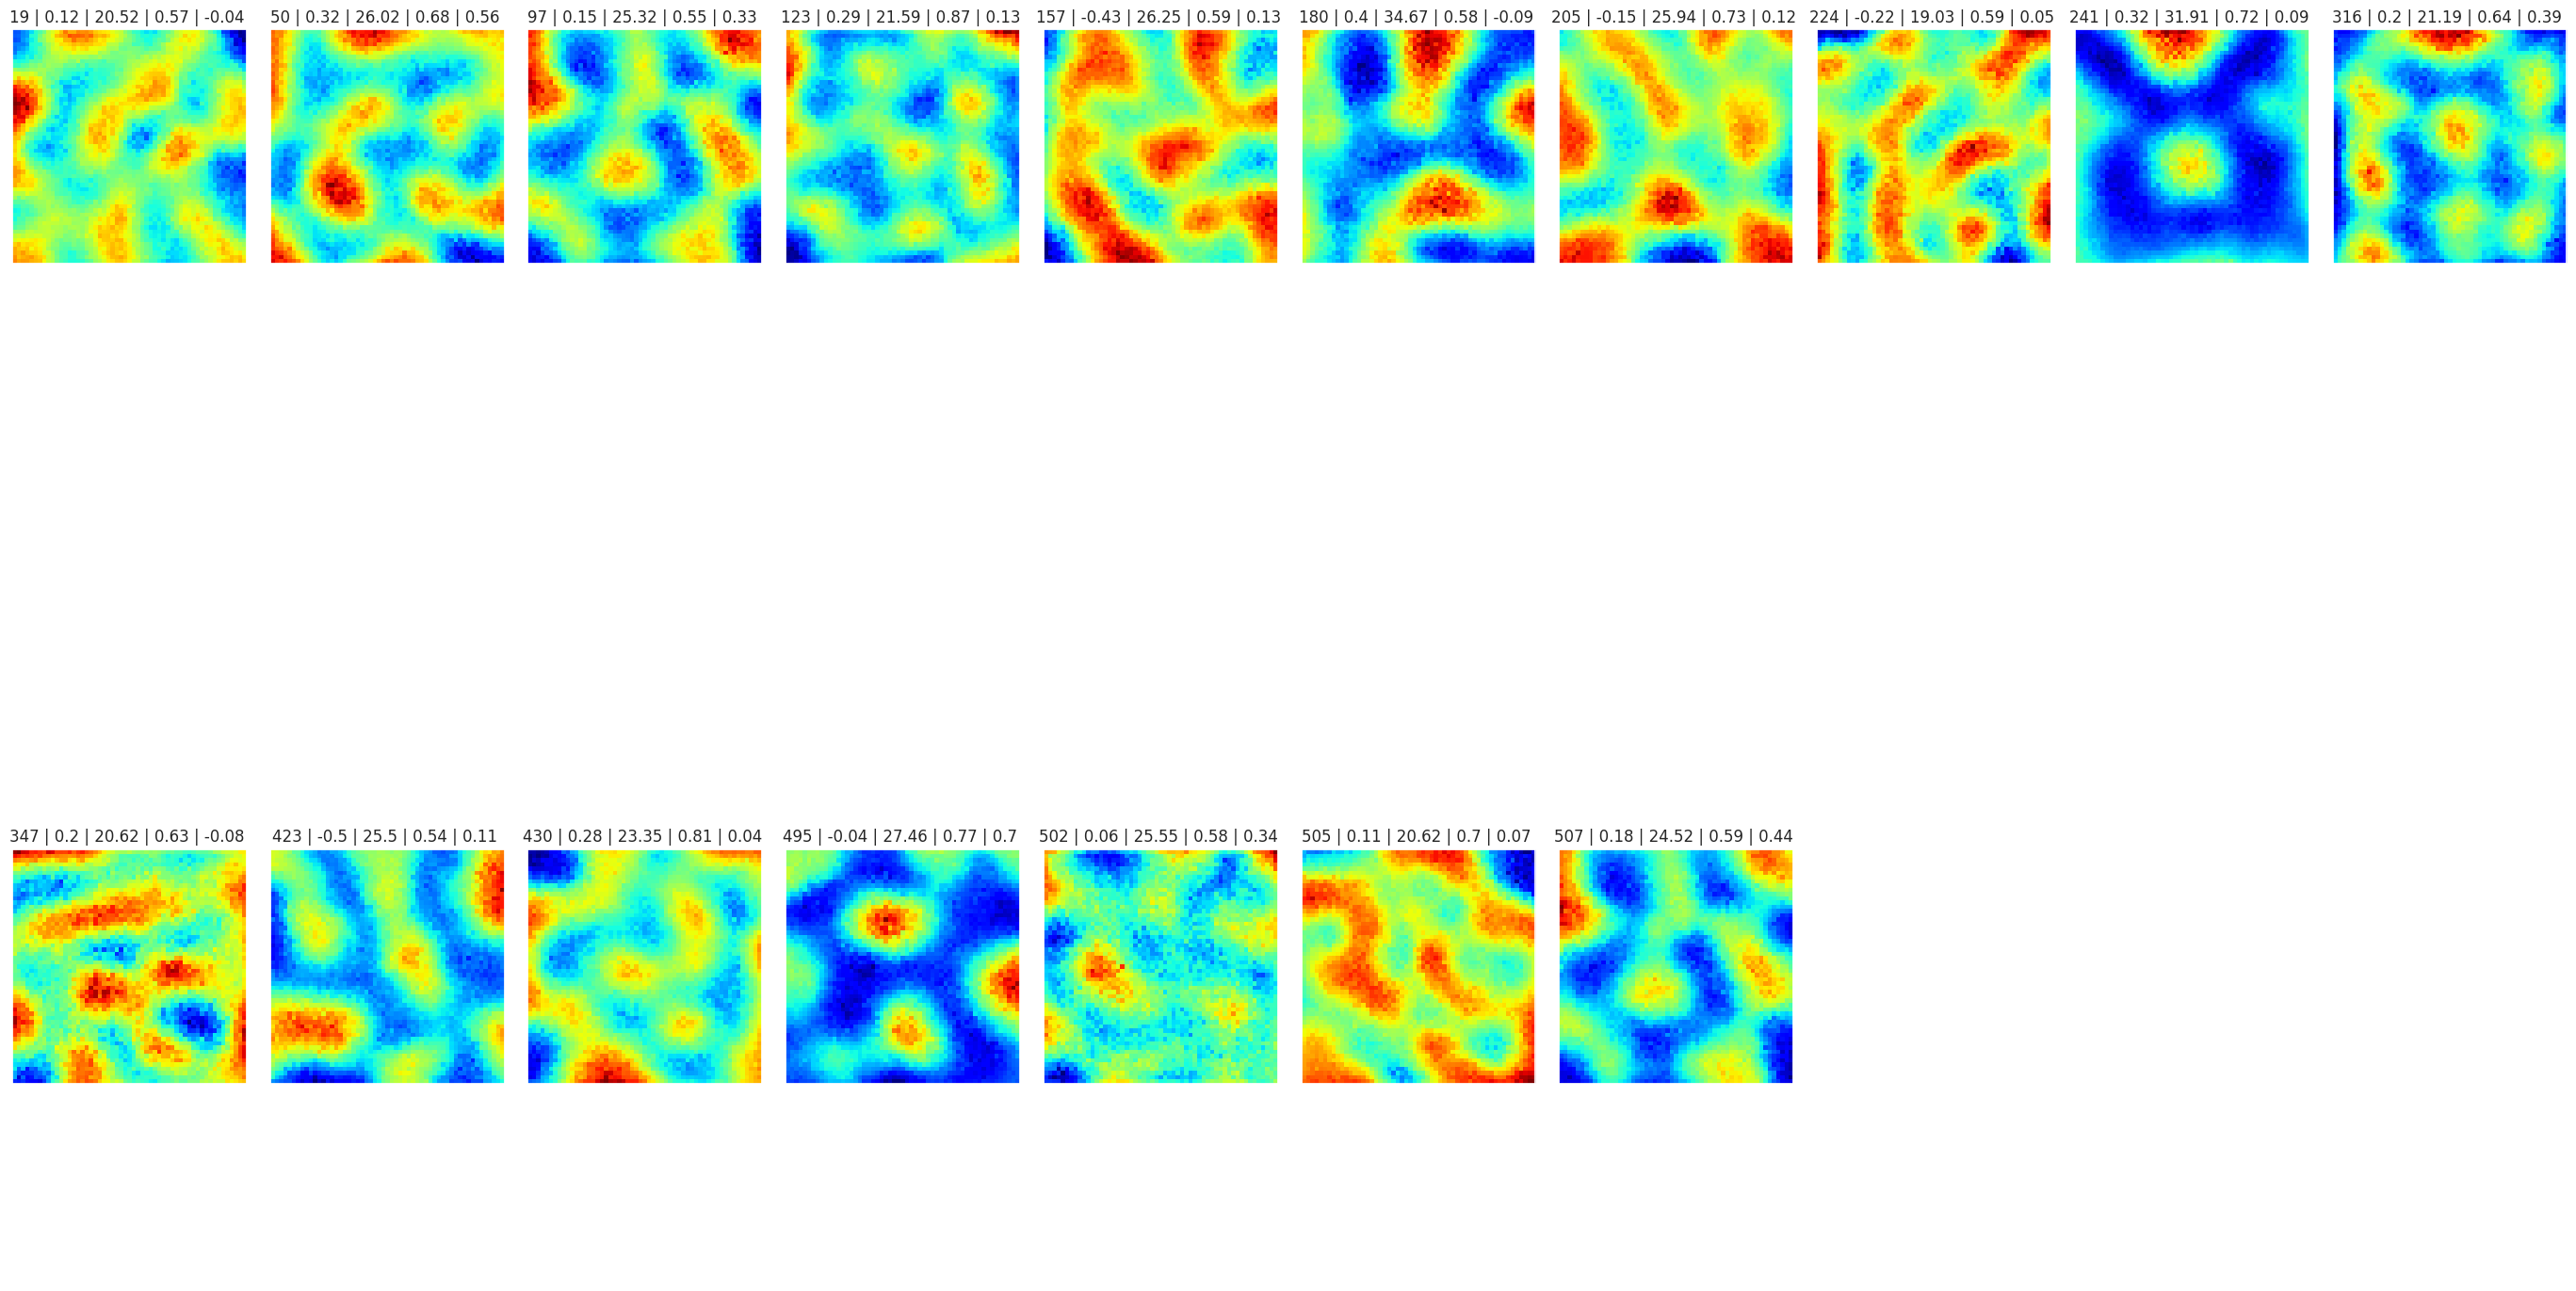

In [14]:
#removable = [[[6, 12, 24], [0, 11, 34], [12, 16], [5, 16, 18, 21, 30, 32, 36], [2, 4, 6, 11, 22, 27], [2, 4, 11, 29, 31], [1, 7, 8, 21]], [[],[],[],[],[],[],[],]]
removable = [[[3, 14, 28, 42, 49, 51, 52, 61, 69], [2, 7, 13, 26, 31, 39, 61, 68, 69, 74], [14, 17, 20, 21, 28, 36, 42, 46, 49, 50, 55, 58, 64, 66, 71, 78, 79], [5, 6, 11, 15, 22, 34, 38, 42, 48, 56, 59, 64, 72, 79], [9, 11, 14, 15, 18, 19, 28, 31, 39, 48, 55, 57, 60, 61, 73, 77, 89], [3, 7, 12, 16, 20, 21, 24, 31, 46, 55, 57, 69, 71, 72, 73, 75], [3, 4, 12, 14, 15, 16, 34, 35, 39, 54, 69, 70, 72]], [[],[15],[],[19],[1, 3, 11],[6],[],]]


sac_max_filter_idx[0] = np.delete(sac_max_filter_idx[0], removable[full_or_max][type_index], 0)
sac_max_median_filt[0] = np.delete(sac_max_median_filt[0], removable[full_or_max][type_index], 0)

for i, m in enumerate( sac_max_median_filt ):

    space_sort_n = sac_max_filter_idx[0] 
    print(space_sort_n)
    ratemap_sample = ratemap_mat[i][ space_sort_n ]
    sac_sample = sac_max_mat[i][ space_sort_n ]

    dim_plot = 10

    fig, axs = plt.subplots( int(np.ceil(space_sort_n.shape[0] / dim_plot)), dim_plot, figsize=( 35, 20 ) )
    fig.subplots_adjust(wspace=0.1, hspace=0.3)

    n = 0
    for a in range( int(np.ceil(space_sort_n.shape[0] / dim_plot)) ):
        for b in range( dim_plot ):

            try:
                axs[a, b].imshow( ratemap[ space_sort_n[n] ], cmap='jet' )
                
                axs[a, b].set_xticks([])  # Remove x-axis ticks
                axs[a, b].set_yticks([])  # Remove y-axis ticks

                axs[a, b].set_title( f'{ space_sort_n[n] } | { round( border_mat[i][ space_sort_n[n] ], 2 ) } | { round( m[ n ], 2 ) } | { round( sac_max_score_60_mat[ i ][ space_sort_n[n] ], 2 ) } | { round( sac_max_score_90_mat[ i ][ space_sort_n[n] ], 2 ) } ' )
            except:
               axs[a, b].axis('off')

            n += 1

    #plt.savefig( f'{ data_path }viz/sac_complete_{ i }.png' )
    plt.show()

## Displaying the grid spacing distribution

(17,)


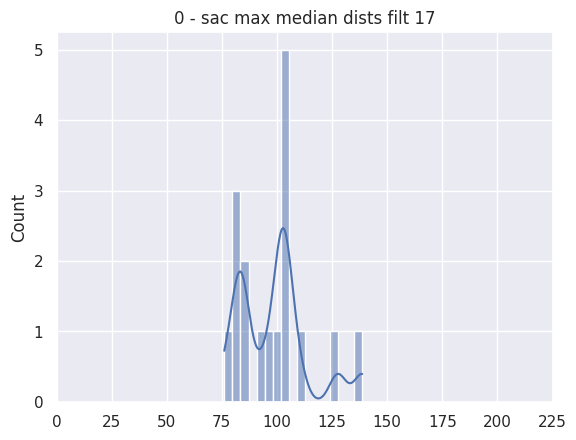

In [15]:
""" 

    independent grid spacing

"""

#sac_max_median_filt = [ x*(0.3/32) for x in sac_max_median_filt ]
sac_max_median_filt = [ x*4 for x in sac_max_median_filt ]

for i, mat in enumerate(sac_max_median_filt):

    fig, ax = plt.subplots( 1, 1 )
    sns.histplot( mat, ax=ax, bins=int(mat.shape[0]), kde=True, legend=False, kde_kws={'bw_adjust': 0.4} )
    print(mat.shape)
    ax.set_title( f'{i} - sac max median dists filt { mat.shape[0] }' )
    #default
    ax.set_xlim(0.0, 225.0)
    #ax.set_xlim( 60.0, 140.0 )

    # save 
    plt.savefig( f'{ data_path }viz/sac_max_median_filt_{ i }.png' )
    np.save( data_path + f'viz/sac_max_median_filt_{ i }.npy', mat )

    plt.show()

## Displaying the units that represented border cells

[1, 28, 43, 51, 52, 80, 86, 93, 102, 112, 115, 116, 144, 176, 198, 208, 212, 222, 238, 273, 277, 281, 284, 298, 299, 305, 322, 326, 330, 358, 366, 368, 376, 382, 400, 411, 426, 431, 471, 488, 498, 500]
42


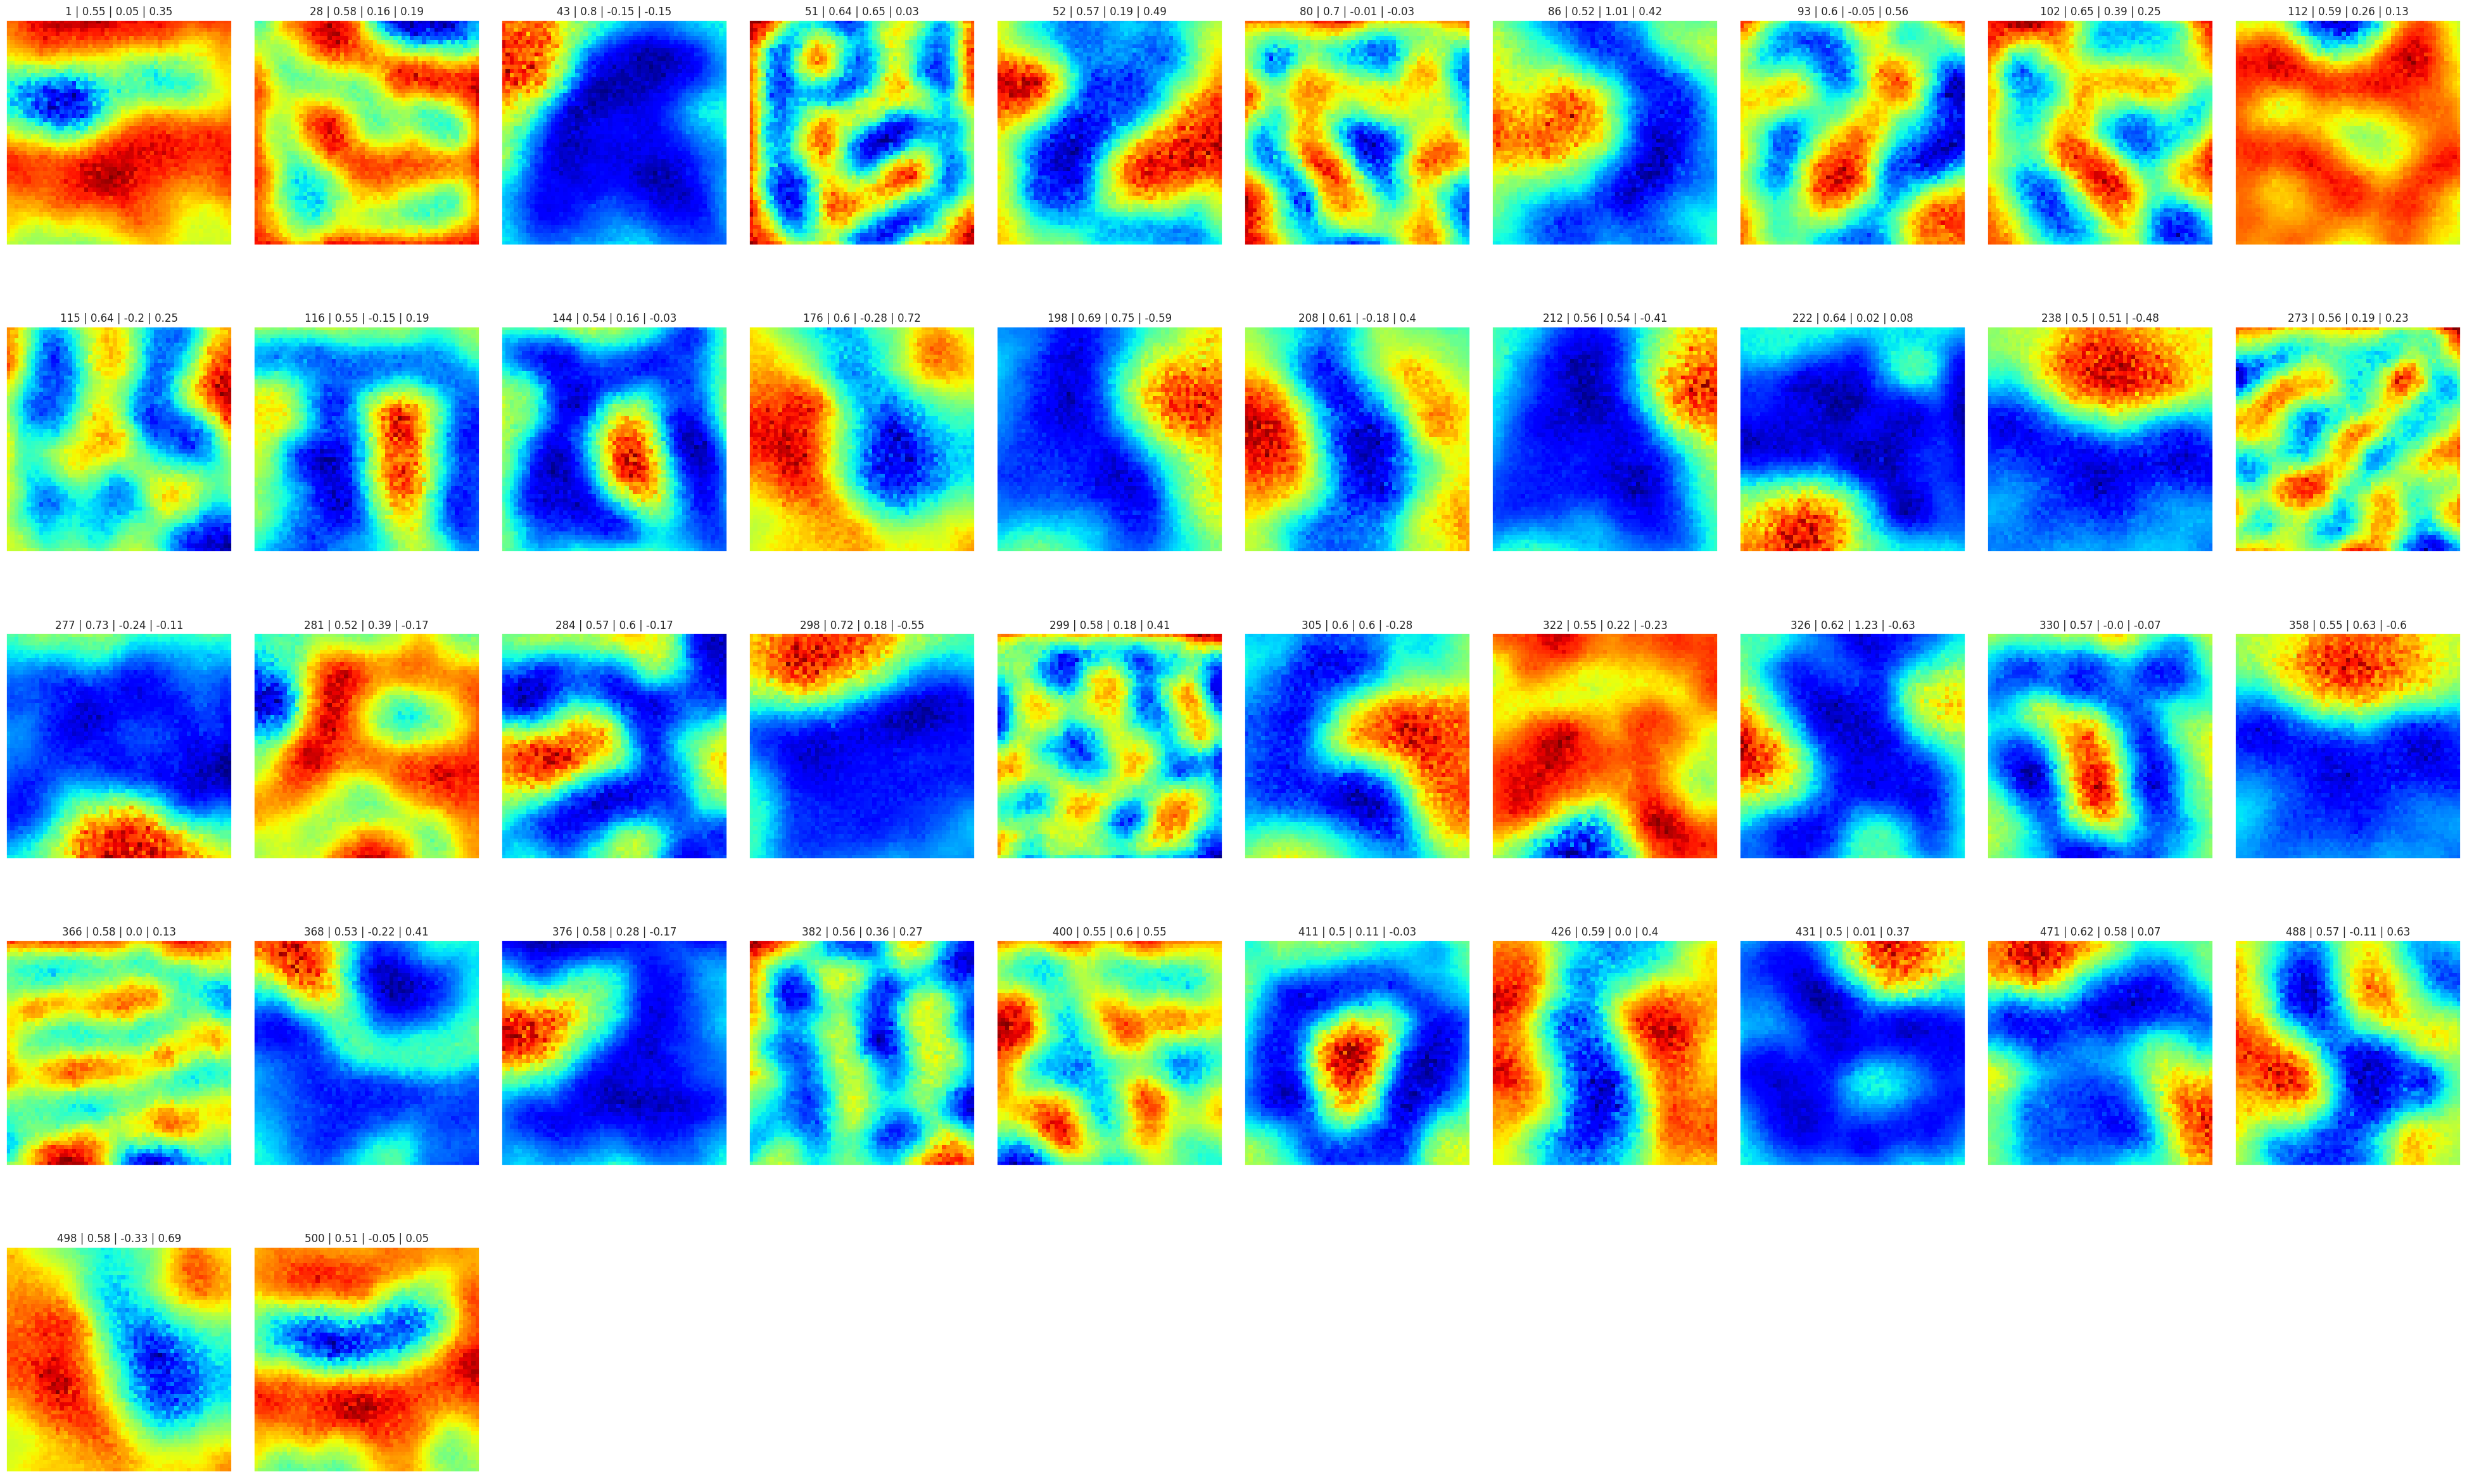

After manual filtering there remained 42 units that represent border cells


In [16]:
#space_sort_2 = [i for i, element in enumerate(ratemap) if i not in border_filt_idx[0]]
space_sort_2 = [i for i, element in enumerate(ratemap) if i not in border_filt_idx[0]]
#filtered_max_median = np.array([element for element in space_sort if element not in removable_idxs])
print(space_sort_2)
print(len(space_sort_2))
dim_plot = 10

fig, axs = plt.subplots( int(np.ceil(len(space_sort_2) / dim_plot)), dim_plot, figsize=( 50, 30 ) )
fig.subplots_adjust(wspace=0.1, hspace=0.3)

n = 0
for a in range( int(np.ceil(len(space_sort_2) / dim_plot)) ):
    for b in range( dim_plot ):

        try:

            axs[a, b].imshow( ratemap[ space_sort_2[n] ], cmap='jet' )

            axs[a, b].set_xticks([])  # Remove x-axis ticks
            axs[a, b].set_yticks([])  # Remove y-axis ticks
            
            #f'{ space_sort_2[n] } | { round( border_mat[0][ space_sort_2[n] ], 2 ) } | { round( m[ space_sort_2[n] ], 2 ) } | { round( sac_max_score_60_mat[ 0 ][ space_sort_2[n] ], 2 ) } | { round( sac_max_score_90_mat[ 0 ][ space_sort_2[n] ], 2 ) } '
            axs[a, b].set_title( f'{ space_sort_2[n] } | { round( border_mat[0][ space_sort_2[n] ], 2 ) } | { round( sac_max_score_60_mat[ 0 ][ space_sort_2[n] ], 2 ) } | { round( sac_max_score_90_mat[ 0 ][ space_sort_2[n] ], 2 ) }' )
        except:
           axs[a, b].axis('off')

        n += 1

plt.show()

print(f"After manual filtering there remained {len(space_sort_2)} units that represent border cells")


## Calculating some percentages on the data

In [17]:
#grid cell percentage
grid_like = len(sac_max_median_filt[0])
percent_grid = grid_like * 100 / 512.00

#border cell percentage
border_cells = 512 - len(border_filt_idx[0])
percent_border = border_cells * 100 / 512

#variation range and mean
min_grid_spacing = np.min(sac_max_median_filt[0])
max_grid_spacing = np.max(sac_max_median_filt[0])
mean_grid_spacing = np.mean(sac_max_median_filt[0])


print(f"The percent of grid-like units from all of the units is: {round(percent_grid, 2)}%")
print(f"The percent of border cells among all of the units is: {round(percent_border, 2)}%")
print(f"The grid spacing varies from {round(min_grid_spacing, 2)} cm to {round(max_grid_spacing, 2)} cm, with the mean of {round(mean_grid_spacing, 2)} cm.")
#Border cells

The percent of grid-like units from all of the units is: 3.32%
The percent of border cells among all of the units is: 8.2%
The grid spacing varies from 76.11 cm to 138.68 cm, with the mean of 98.83 cm.
